# Построение агентной системы на Python

Данная работа посвящена построению агентных систем на LangChain и LangGraph.

Данная работа выполнена студентом ИАД-4 Коноваловым Матвеем и опирается на семинарские ноутбуки.

## В чём разница между LangChain и LangGraph

| Характеристика | LangChain Agents | LangGraph Agents |
|----------------|-----------------|-----------------|
| Кто управляет логикой | Модель (LLM) | Разработчик |
| Гибкость | Ограничена | Абсолютная |
| Сложность | Простые / средние задачи | Сложные воркфлоу |
| Предсказуемость | Низкая | Высокая |
| Память | Минимальная | Любая, структурированная |
| Подходит для продакшена | Иногда | Да |

---

## Вывод

- **LangChain Agents** — быстрый способ собрать помощника: подключаем инструменты, выбираем тип агента, LLM сама решает, что делать.
- **LangGraph Agents** — контроль над каждым шагом: вы строите граф действий, LLM участвует только в отдельных узлах, что делает систему предсказуемой и надёжной.

**Итоговое правило:**
LangChain = “готовые блоки, которые магически вызывают инструменты”
LangGraph = “строим агента сами, LLM помогает на узлах, а логика полностью под нашим контролем”

## Инициализация LLM
LLM это неотъемлемая часть агентных систем, центральный мозг, вызывающий конкретные инструменты или выполняющий работу с текстом, так что без неё мы в этой работе не обойдемся.

Выбор модели проводился на основании [ранкинга LLM в категории Academia на OpenRouter](https://openrouter.ai/rankings?category=academia#categories) (поскольку обе агентных системы связаны с наукой)

In [ ]:
!pip install -qU langchain==0.3.25 langchain-openai==0.3.22 langchain-experimental==0.3.4 numexpr==2.11.0

In [5]:
from langchain_openai import ChatOpenAI
from constants import OPENROUTER_API_KEY

llm = ChatOpenAI(
    model="stepfun/step-3.5-flash:free",
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
    temperature=0,
)

## ReAct-агент на LangChain

Было бы круто что-то придумать с md-подписями для клеток, и мб с написанием md-саммари (или хотя бы выводов).

И раз он многофункциональный, то можно ещё анализ кода на соответствие поставленной задаче закинуть.

## Агент на LangGraph
Агент должен обращаться по API, обрабатывать ответ LLM-кой и выдавать в ответе, причем должна решаться полезная для меня задача.

В ходе написания кода для исследований меня часто посещает вопрос "а точно ли то, чем я сейчас занимаюсь, не рассматривалось кем-то в статье?".

Поэтому мой агент будет читать мой код, искать релевантные статьи через API arXiv и саммаризировать для меня, какие вопросы полностью затрагивались, что упоминалось частично, а что представляет научную новизну.

In [2]:
!pip install -q langgraph==0.2.76 arxiv charset_normalizer

  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 0.3.83
    Uninstalling langchain-core-0.3.83:
      Successfully uninstalled langchain-core-0.3.83
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [langgraph]/6 [langchain-core]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-community 0.3.25 requires langchain-core<1.0.0,>=0.3.65, but you have langchain-core 1.2.20 which is incompatible.
langchain-experimental 0.3.4 requires langchain-core<0.4.0,>=0.3.28, but you have langchain-core 1.2.20 which is incompatible.
langchain 0.3.25 requires langchain-core<1.0.0,>=0.3.58, but you have langchain-core 1.2.20 which is incompatible.
langchain-openai 0.3.22 requires langchain-core<1.0.0,>=0.3.64, but you have langchain-core 1.2.20 which is incompatible.


In [25]:
from typing import TypedDict, List, Dict, Any
import json
import textwrap
import arxiv
from langgraph.graph import START, END, StateGraph

In [26]:
class AgentState(TypedDict, total=False):
    code: str
    code_summary: str
    extracted_signals: Dict[str, Any]
    algorithmic_structure: Dict[str, Any]
    queries: List[str]
    papers: List[Dict[str, str]]
    paper_algorithms: List[Dict[str, Any]]
    paper_matches: List[Dict[str, Any]]
    final_summary: str

In [27]:
VERBOSE = True
TOP_PAPERS_FOR_ALGO_EXTRACTION = 12
TOP_PAPERS_FOR_MATCHING = 8

### Шаг 1. Извлечение сигналов из кода

Здесь LLM-ка, подобно backbone, извлекающему признаки с картинки, извлекает сигналы из кода, по которым дальше будет происходить поиск релевантных статей.

In [28]:
def summarize_code(state: AgentState):
    prompt = f"""
Ты анализируешь код исследовательского проекта и готовишь его описание для поиска научных статей.

Нужно вернуть JSON-объект со следующими полями:
- task: краткое название задачи;
- method_kind: тип метода или эксперимента;
- keywords: список ключевых терминов из кода;
- concepts: список более общих исследовательских концептов;
- method_markers: список используемых технических методов и механизмов;
- search_hints: 3-6 коротких поисковых фраз для arXiv.

Вот несколько примеров method_markers (они не обязательно представлены и ты можешь использовать пример не из списка):
- важность через градиент выхода по промежуточному слою;
- feature-level objective;
- интегрирование по пути от baseline к входу;
- итеративная атака с проекцией в L_inf-шар;
- momentum update;
- hook на промежуточный слой;
- сравнение важных и атакованных фич;
- корреляционный или иной анализ связи важности и атаки.

Ответ верни строго в формате JSON без пояснений.

Код:
{state['code']}
"""

    result = llm.invoke(prompt).content
    if VERBOSE:
        print("summarize_code raw result:\n", result)

    try:
        extracted_signals = json.loads(result)
    except Exception:
        extracted_signals = {
            "task": "unknown",
            "method_kind": "unknown",
            "keywords": [],
            "concepts": [],
            "method_markers": [],
            "search_hints": []
        }

    code_summary = textwrap.dedent(
        f"""
        Task: {extracted_signals.get('task', 'unknown')}
        Method kind: {extracted_signals.get('method_kind', 'unknown')}
        Keywords: {', '.join(extracted_signals.get('keywords', []))}
        Concepts: {', '.join(extracted_signals.get('concepts', []))}
        Method markers: {', '.join(extracted_signals.get('method_markers', []))}
        """
    ).strip()

    if VERBOSE:
        print("Parsed extracted_signals:", extracted_signals)

    return {
        "extracted_signals": extracted_signals,
        "code_summary": code_summary,
    }

### Шаг 2. Извлечение алгоритмической структуры и исследовательского вопроса

Одних общих сигналов недостаточно: для точного поиска статей нужно отдельно извлечь алгоритмический скелет кода. На этом шаге LLM формирует более строгую структуру: основной алгоритм, исследовательский вопрос, используемые методы, характерные шаги процедуры и ключевые фрагменты кода, которые потом пойдут в финальное сопоставление со статьями.

In [30]:
def extract_algorithmic_structure(state: AgentState):
    prompt = f"""
Ты анализируешь код исследовательского проекта. Тебе нужно извлечь не общую тему, а алгоритмическую структуру и исследовательский вопрос.

Верни строго JSON-объект со следующими полями:
- research_question: главный исследовательский вопрос или проверяемая гипотеза;
- algorithm_type: краткий тип алгоритма;
- algorithm_signature: список из 4-8 коротких шагов, описывающих основную процедуру;
- methods_used: список используемых методов и механизмов;
- implementation_markers: список важных технических деталей реализации;
- key_code_spans: список из 3-6 коротких фрагментов кода или псевдокода, которые лучше всего описывают основной алгоритм.

Важно:
- methods_used должен явно выделять используемые методы, например: gradient of class score w.r.t. intermediate features, path integration, feature attribution, feature-level attack objective, momentum iterative update, Linf projection, hook-based feature extraction, comparison of important vs attacked features, attribution/perturbation alignment analysis;
- algorithm_signature должен описывать именно ход алгоритма, а не просто перечислять ключевые слова;
- key_code_spans должны быть короткими, но содержательными и буквально опираться на код.

Ответ верни строго в формате JSON без пояснений.

Код:
{state['code']}
"""

    result = llm.invoke(prompt).content
    if VERBOSE:
        print("extract_algorithmic_structure raw result:\n", result)

    try:
        algorithmic_structure = json.loads(result)
    except Exception:
        algorithmic_structure = {
            "research_question": "unknown",
            "algorithm_type": "unknown",
            "algorithm_signature": [],
            "methods_used": [],
            "implementation_markers": [],
            "key_code_spans": []
        }

    if VERBOSE:
        print("Parsed algorithmic_structure:", algorithmic_structure)

    return {"algorithmic_structure": algorithmic_structure}

### Шаг 3. Построение нескольких поисковых запросов

Чтобы повысить полноту поиска, агент строит не один запрос, а несколько: более буквальные и более концептуальные. Задача - накидать побольше статей и уже потом среди них выделить самые релевантные, ибо важно не пропустить ни одной статьи, которая повторяет подходы из кода

In [32]:
def build_queries(state: AgentState):
    signals = state["extracted_signals"]
    algorithmic_structure = state["algorithmic_structure"]

    prompt = f"""
На основе двух структур ниже составь от 8 до 12 поисковых запросов для arXiv.

Требования:
- запросы должны быть короткими;
- часть запросов должна быть буквальной (по терминам из кода), часть — по алгоритмической структуре, часть — по исследовательскому вопросу;
- если в структуре есть `search_hints`, обязательно используй их как основу хотя бы для части запросов;
- обязательно используй `methods_used`, `algorithm_signature` и `research_question`, а не только keywords;
- каждый запрос верни на новой строке;
- не нумеруй строки;
- не добавляй пояснения.

Общая структура:
{json.dumps(signals, ensure_ascii=False, indent=2)}

Алгоритмическая структура:
{json.dumps(algorithmic_structure, ensure_ascii=False, indent=2)}
"""

    result = llm.invoke(prompt).content
    if VERBOSE:
        print("build_queries raw result:\n", result)

    queries = [line.strip("-• \t") for line in result.splitlines() if line.strip()]
    queries = list(dict.fromkeys(queries))

    search_hints = signals.get("search_hints", [])
    queries.extend([hint for hint in search_hints if hint not in queries])
    queries = list(dict.fromkeys(queries))

    if VERBOSE:
        print("Queries:", queries)

    return {"queries": queries}

### Шаг 4. Поиск статей через arXiv API

Наконец этап без LLM, но с обращением по API. Для каждого запроса берём несколько результатов, после чего объединяем их и убираем дубликаты по названию статьи.

In [34]:
def get_papers(state: AgentState):
    queries = state["queries"]
    papers: List[Dict[str, str]] = []
    seen_titles = set()

    client = arxiv.Client(page_size=5, delay_seconds=0.5, num_retries=3)

    for query in queries:
        if VERBOSE:
            print(f"Searching arXiv for query: {query}")

        search = arxiv.Search(
            query=query,
            max_results=5,
            sort_by=arxiv.SortCriterion.Relevance,
        )

        try:
            for result in client.results(search):
                title_key = result.title.strip().lower()
                if title_key in seen_titles:
                    continue

                seen_titles.add(title_key)
                papers.append(
                    {
                        "query": query,
                        "title": result.title,
                        "summary": result.summary,
                        "published": str(result.published.date()),
                        "url": result.entry_id,
                    }
                )
        except Exception as e:
            if VERBOSE:
                print(f"arXiv request failed for query '{query}': {e}")

    if VERBOSE:
        print(f"Total unique papers found: {len(papers)}")

    return {"papers": papers}

### Шаг 5. Извлечение алгоритмов из найденных статей

Теперь агент переходит от простого списка статей к их структурированному сравнению с кодом. Для наиболее релевантных на первый взгляд статей он извлекает не просто summary, а тип метода, исследовательский вопрос, алгоритмические шаги и используемые механизмы.

In [35]:
def extract_paper_algorithms(state: AgentState):
    papers = state.get("papers", [])[:TOP_PAPERS_FOR_ALGO_EXTRACTION]
    paper_algorithms: List[Dict[str, Any]] = []

    for paper in papers:
        prompt = f"""
У тебя есть краткая информация о научной статье. Извлеки из неё алгоритмическое описание.

Верни строго JSON-объект со следующими полями:
- title: название статьи;
- paper_task: основная задача статьи;
- paper_research_question: исследовательский вопрос статьи;
- paper_method_kind: тип метода;
- paper_algorithm_signature: список из 3-7 коротких шагов алгоритма или процедуры;
- paper_methods_used: список используемых методов и механизмов;
- paper_key_mechanisms: список ключевых технических идей статьи.

Статья:
Title: {paper['title']}
Published: {paper['published']}
Source query: {paper['query']}
Summary: {paper['summary']}
URL: {paper['url']}
"""

        result = llm.invoke(prompt).content
        if VERBOSE:
            print(f"extract_paper_algorithms raw result for '{paper['title']}':\n", result)

        try:
            parsed = json.loads(result)
        except Exception:
            parsed = {
                "title": paper["title"],
                "paper_task": "unknown",
                "paper_research_question": "unknown",
                "paper_method_kind": "unknown",
                "paper_algorithm_signature": [],
                "paper_methods_used": [],
                "paper_key_mechanisms": []
            }

        parsed["summary"] = paper["summary"]
        parsed["published"] = paper["published"]
        parsed["query"] = paper["query"]
        parsed["url"] = paper["url"]
        paper_algorithms.append(parsed)

    if VERBOSE:
        print("Structured paper algorithms count:", len(paper_algorithms))

    return {"paper_algorithms": paper_algorithms}

### Шаг 6. Сопоставление кода и статей по алгоритмической структуре

Здесь агент уже сравнивает не просто ключевые слова, а две структуры: алгоритм в коде и алгоритм в статье. Это позволяет отделить почти точные совпадения от частичных пересечений и фоновых работ.

In [36]:
def match_code_to_papers(state: AgentState):
    algorithmic_structure = state["algorithmic_structure"]
    paper_algorithms = state.get("paper_algorithms", [])[:TOP_PAPERS_FOR_MATCHING]
    paper_matches: List[Dict[str, Any]] = []

    for paper in paper_algorithms:
        prompt = f"""
У тебя есть структура алгоритма из кода и структура алгоритма из статьи. Сопоставь их.

Верни строго JSON-объект со следующими полями:
- title: название статьи;
- match_level: one_to_one | partial | background;
- matched_steps: список шагов или идей, которые совпадают;
- missing_steps: список шагов или идей из кода, которых не видно в статье;
- method_overlap: список совпадающих методов и механизмов;
- verdict: короткий вывод на русском языке, насколько статья реально покрывает происходящее в коде.

Структура алгоритма из кода:
{json.dumps(algorithmic_structure, ensure_ascii=False, indent=2)}

Структура статьи:
{json.dumps(paper, ensure_ascii=False, indent=2)}
"""

        result = llm.invoke(prompt).content
        if VERBOSE:
            print(f"match_code_to_papers raw result for '{paper['title']}':\n", result)

        try:
            parsed = json.loads(result)
        except Exception:
            parsed = {
                "title": paper["title"],
                "match_level": "background",
                "matched_steps": [],
                "missing_steps": [],
                "method_overlap": [],
                "verdict": "Не удалось надёжно сопоставить статью с кодом по алгоритмической структуре."
            }

        parsed["published"] = paper.get("published", "")
        parsed["url"] = paper.get("url", "")
        parsed["paper_task"] = paper.get("paper_task", "")
        parsed["paper_method_kind"] = paper.get("paper_method_kind", "")
        paper_matches.append(parsed)

    if VERBOSE:
        print("Structured paper matches count:", len(paper_matches))

    return {"paper_matches": paper_matches}

### Шаг 7. Финальное саммари найденных статей

Теперь LLM компактное описание кода плюс найденные статьи, а так же основные алгоритмы. По ним агент должен сделать итоговое саммари и разделить результаты на три уровня релевантности.

In [37]:
def summarize_papers(state: AgentState):
    papers = state.get("papers", [])
    algorithmic_structure = state.get("algorithmic_structure", {})
    paper_algorithms = state.get("paper_algorithms", [])
    paper_matches = state.get("paper_matches", [])

    if not papers:
        return {
            "final_summary": "По сформированным запросам статьи в arXiv найти не удалось. Возможно, запросы стоит расширить или сделать более общими."
        }

    papers_text = "\n\n".join(
        [
            textwrap.dedent(
                f"""
                Title: {paper['title']}
                Published: {paper['published']}
                Source query: {paper['query']}
                Summary: {paper['summary']}
                URL: {paper['url']}
                """
            ).strip()
            for paper in papers[:15]
        ]
    )

    paper_algorithms_text = "\n\n".join(
        [
            textwrap.dedent(
                f"""
                Title: {paper.get('title', '')}
                Paper task: {paper.get('paper_task', '')}
                Paper research question: {paper.get('paper_research_question', '')}
                Paper method kind: {paper.get('paper_method_kind', '')}
                Paper algorithm signature: {', '.join(paper.get('paper_algorithm_signature', []))}
                Paper methods used: {', '.join(paper.get('paper_methods_used', []))}
                Paper key mechanisms: {', '.join(paper.get('paper_key_mechanisms', []))}
                URL: {paper.get('url', '')}
                """
            ).strip()
            for paper in paper_algorithms
        ]
    )

    paper_matches_text = "\n\n".join(
        [
            textwrap.dedent(
                f"""
                Title: {match.get('title', '')}
                Match level: {match.get('match_level', '')}
                Matched steps: {', '.join(match.get('matched_steps', []))}
                Missing steps: {', '.join(match.get('missing_steps', []))}
                Method overlap: {', '.join(match.get('method_overlap', []))}
                Verdict: {match.get('verdict', '')}
                URL: {match.get('url', '')}
                """
            ).strip()
            for match in paper_matches
        ]
    )

    prompt = f"""
У тебя есть краткое описание кода, его алгоритмическая структура, ключевые фрагменты кода и найденные по arXiv статьи.

Описание кода:
{state['code_summary']}

Алгоритмическая структура кода:
{json.dumps(algorithmic_structure, ensure_ascii=False, indent=2)}

Исходные найденные статьи:
{papers_text}

Извлечённые алгоритмы статей:
{paper_algorithms_text}

Сопоставление кода и статей:
{paper_matches_text}

Сделай итоговое саммари на русском языке в следующей структуре:
1. Статьи, где это уже есть почти один в один
2. Частично релевантные статьи
3. Фоновые, но полезные статьи
4. Что в коде выглядит потенциально новым или по крайней мере неочевидно покрытым найденными статьями

Главный вопрос, на который ты отвечаешь: происходящее в этом коде уже рассматривалось в литературе почти один в один, или здесь действительно есть элементы научной новизны?

Важно:
- опирайся не только на общие слова, но и на algorithm_signature, methods_used, implementation_markers и key_code_spans;
- если совпадает сам алгоритмический скелет, пиши, что это почти один в один;
- если совпадает только идея или часть механики, относись к статье как к частично релевантной;
- если статья просто про смежную область, укажи это явно.

Пиши компактно, но содержательно. Для каждой статьи указывай её название и явно поясняй, является ли она совпадением почти один в один, только частичным совпадением, или просто фоново полезной.
"""

    if VERBOSE:
        print("FINAL PROMPT:\n", prompt)

    result = llm.invoke(prompt).content
    result = result.replace("### Итоговое саммари\n\n", "", 1)

    if VERBOSE:
        print("summarize_papers result:\n", result)

    return {"final_summary": result}

### Сборка графа

Граф получается линейным и полностью контролируемым: сначала извлекаются общие сигналы, потом алгоритмическая структура, затем строятся запросы, идёт поиск по API, после чего агент извлекает алгоритмы из статей, сопоставляет их с кодом и только потом формирует итоговый вывод.

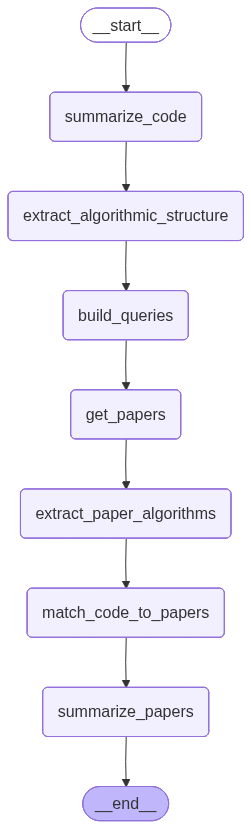

In [38]:
graph_builder = StateGraph(AgentState)

graph_builder.add_node("summarize_code", summarize_code)
graph_builder.add_node("extract_algorithmic_structure", extract_algorithmic_structure)
graph_builder.add_node("build_queries", build_queries)
graph_builder.add_node("get_papers", get_papers)
graph_builder.add_node("extract_paper_algorithms", extract_paper_algorithms)
graph_builder.add_node("match_code_to_papers", match_code_to_papers)
graph_builder.add_node("summarize_papers", summarize_papers)

graph_builder.add_edge(START, "summarize_code")
graph_builder.add_edge("summarize_code", "extract_algorithmic_structure")
graph_builder.add_edge("extract_algorithmic_structure", "build_queries")
graph_builder.add_edge("build_queries", "get_papers")
graph_builder.add_edge("get_papers", "extract_paper_algorithms")
graph_builder.add_edge("extract_paper_algorithms", "match_code_to_papers")
graph_builder.add_edge("match_code_to_papers", "summarize_papers")
graph_builder.add_edge("summarize_papers", END)

graph = graph_builder.compile()
graph

## Тесты агента

### Mock-примеры
Здесь приведены достаточно типичные куски кода, на которые модель должна однозначно сказать "исследовано здесь, новизны ноль"

In [39]:
example_code = """
import torch
import torch.nn.functional as F

model.eval()
layer = model.layer3[-1]
steps = 10
attack_steps = 20
eps = 16 / 255
alpha = 2 / 255
mu = 1.0

mean = torch.tensor([0.485, 0.456, 0.406], device=x.device).view(1, 3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225], device=x.device).view(1, 3, 1, 1)


def forward_features(inp):
    feats = {}

    def hook(_, __, output):
        feats["value"] = output

    handle = layer.register_forward_hook(hook)
    logits = model((inp - mean) / std)
    handle.remove()
    return logits, feats["value"]


with torch.no_grad():
    clean_logits, clean_mid = forward_features(x)
    y = clean_logits.argmax(dim=1)

baseline = torch.zeros_like(x)
attr = torch.zeros_like(clean_mid)

for k in range(1, steps + 1):
    a = k / steps
    x_interp = baseline + a * (x - baseline)
    x_interp.requires_grad_(True)
    logits_interp, mid_interp = forward_features(x_interp)
    score = logits_interp.gather(1, y[:, None]).sum()
    grad_mid = torch.autograd.grad(score, mid_interp)[0]
    attr = attr + grad_mid * mid_interp / steps

weights = attr.mean(dim=(2, 3), keepdim=True)
weights = torch.relu(weights)
weights = weights / (weights.abs().mean(dim=(1, 2, 3), keepdim=True) + 1e-12)

delta = torch.zeros_like(x, requires_grad=True)
momentum = torch.zeros_like(x)

for _ in range(attack_steps):
    adv = (x + delta).clamp(0, 1)
    _, adv_mid = forward_features(adv)

    feature_loss = -(weights * adv_mid).sum(dim=(1, 2, 3)).mean()
    image_loss = 0.05 * (adv - x).pow(2).mean()
    loss = feature_loss + image_loss

    grad = torch.autograd.grad(loss, delta)[0]
    grad = grad / (grad.abs().mean(dim=(1, 2, 3), keepdim=True) + 1e-12)
    momentum = mu * momentum + grad

    delta.data = delta.data + alpha * momentum.sign()
    delta.data.clamp_(-eps, eps)
    delta.data = ((x + delta.data).clamp(0, 1) - x).detach()
    delta.grad = None

x_adv = (x + delta).clamp(0, 1)
"""

result = graph.invoke({"code": example_code})
print(result["final_summary"])

summarize_code raw result:
 {
  "task": "Adversarial attack by suppressing feature importance",
  "method_kind": "Gradient-based adversarial attack with feature attribution",
  "keywords": [
    "adversarial attack",
    "feature importance",
    "gradient attribution",
    "integrated gradients",
    "momentum method",
    "L_inf norm",
    "intermediate layer",
    "forward hook",
    "feature loss",
    "clamping"
  ],
  "concepts": [
    "adversarial machine learning",
    "model interpretability",
    "gradient-based methods",
    "feature manipulation",
    "robustness"
  ],
  "method_markers": [
    "importance via gradient of output w.r.t. intermediate layer",
    "feature-level objective",
    "integration along path from baseline to input",
    "iterative attack with L_inf projection",
    "momentum update",
    "hook on intermediate layer",
    "suppression of important features"
  ],
  "search_hints": [
    "adversarial attack feature importance",
    "gradient attribution 

KeyboardInterrupt: 

In [ ]:
from IPython.display import display, Markdown

display(Markdown((result["final_summary"])))

# Тестовые клетки
TODO: удалить

In [41]:
from pprint import pprint

paper_id = "2204.00008"
client = arxiv.Client(page_size=1, delay_seconds=0.5, num_retries=3)
search = arxiv.Search(id_list=[paper_id])
result = next(client.results(search))

pprint(result, sort_dicts=False)


arxiv.Result(entry_id='http://arxiv.org/abs/2204.00008v1', updated=datetime.datetime(2022, 3, 31, 13, 47, 30, tzinfo=datetime.timezone.utc), published=datetime.datetime(2022, 3, 31, 13, 47, 30, tzinfo=datetime.timezone.utc), title='Improving Adversarial Transferability via Neuron Attribution-Based Attacks', authors=[arxiv.Result.Author('Jianping Zhang'), arxiv.Result.Author('Weibin Wu'), arxiv.Result.Author('Jen-tse Huang'), arxiv.Result.Author('Yizhan Huang'), arxiv.Result.Author('Wenxuan Wang'), arxiv.Result.Author('Yuxin Su'), arxiv.Result.Author('Michael R. Lyu')], summary="Deep neural networks (DNNs) are known to be vulnerable to adversarial examples. It is thus imperative to devise effective attack algorithms to identify the deficiencies of DNNs beforehand in security-sensitive applications. To efficiently tackle the black-box setting where the target model's particulars are unknown, feature-level transfer-based attacks propose to contaminate the intermediate feature outputs of l

## Отдельный тест: извлечение алгоритма статьи по полной главе метода

Перед тем как встраивать извлечение алгоритма статьи в основной пайплайн, полезно отдельно проверить, насколько хорошо получается восстанавливать алгоритмическую структуру не по одному abstract, а по полной наиболее вероятной главе с методом/подходом, извлечённой из PDF статьи.

Для извлечения главы с алгоритмом используется Grobid, его нужно развернуть в виде сервера, лучше всего через Docker.

Как бы я ни хотел, более простого метода я не нашел.

При этом он занимает достаточно много оперативной памяти, и я точно буду его забывать закрывать, так что предпочту запускать его на час. Если часа окажется мало, можно увеличить количество времени.

In [62]:
import threading
import subprocess
import time

CONTAINER_NAME = "grobid"
IMAGE = "lfoppiano/grobid:latest-crf"
PORT = "8070:8070"
CONTAINER_TIMEOUT = 3600  # секунд (1 час)

def is_running(name):
    result = subprocess.run(
        ["docker", "inspect", "-f", "{{.State.Running}}", name],
        capture_output=True, text=True
    )
    return result.returncode == 0 and result.stdout.strip() == "true"

def exists(name):
    result = subprocess.run(
        ["docker", "inspect", name],
        stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
    )
    return result.returncode == 0

def start_container():
    if is_running(CONTAINER_NAME):
        print("Container already running")
        return

    if exists(CONTAINER_NAME):
        print("Starting existing container...")
        subprocess.run(["docker", "start", CONTAINER_NAME], check=True)
    else:
        print("Creating and starting container...")
        subprocess.run([
            "docker", "run", "-d",
            "-p", PORT,
            "--name", CONTAINER_NAME,
            IMAGE
        ], check=True)

def stop_later():
    time.sleep(CONTAINER_TIMEOUT)
    print("Stopping container...")
    subprocess.run(["docker", "stop", CONTAINER_NAME])

# запуск
start_container()

# таймер на остановку
threading.Thread(target=stop_later, daemon=True).start()

Container already running


In [51]:
from pprint import pprint
from typing import Dict, Any, List
import json
import re
import requests
import fitz  # PyMuPDF
import arxiv


def clean_json_response(text: str) -> str:
    text = text.strip()

    if text.startswith("```"):
        text = re.sub(r"^```(?:json)?\s*", "", text)
        text = re.sub(r"\s*```$", "", text)

    start_obj = text.find("{")
    end_obj = text.rfind("}")
    start_arr = text.find("[")
    end_arr = text.rfind("]")

    if start_obj != -1 and end_obj != -1 and end_obj > start_obj:
        return text[start_obj:end_obj + 1].strip()
    if start_arr != -1 and end_arr != -1 and end_arr > start_arr:
        return text[start_arr:end_arr + 1].strip()

    return text.strip()


def fetch_arxiv_paper_by_id(paper_id: str) -> Dict[str, Any]:
    client = arxiv.Client(page_size=1, delay_seconds=0.5, num_retries=3)
    search = arxiv.Search(id_list=[paper_id])
    result = next(client.results(search))

    return {
        "entry_id": result.entry_id,
        "title": result.title,
        "authors": [author.name for author in result.authors],
        "published": str(result.published),
        "updated": str(result.updated),
        "primary_category": result.primary_category,
        "categories": result.categories,
        "summary": result.summary,
        "comment": result.comment,
        "journal_ref": result.journal_ref,
        "doi": result.doi,
        "pdf_url": result.pdf_url,
        "links": [link.href for link in result.links],
    }


def fetch_arxiv_paper_by_title(title: str, max_results: int = 5) -> Dict[str, Any]:
    client = arxiv.Client(page_size=max_results, delay_seconds=0.5, num_retries=3)
    search = arxiv.Search(
        query=f'ti:"{title}"',
        max_results=max_results,
        sort_by=arxiv.SortCriterion.Relevance,
    )

    results = list(client.results(search))
    if not results:
        raise ValueError(f"Статья с title={title!r} не найдена")

    result = results[0]
    return {
        "entry_id": result.entry_id,
        "title": result.title,
        "authors": [author.name for author in result.authors],
        "published": str(result.published),
        "updated": str(result.updated),
        "primary_category": result.primary_category,
        "categories": result.categories,
        "summary": result.summary,
        "comment": result.comment,
        "journal_ref": result.journal_ref,
        "doi": result.doi,
        "pdf_url": result.pdf_url,
        "links": [link.href for link in result.links],
    }


def download_pdf_bytes(pdf_url: str) -> bytes:
    response = requests.get(pdf_url, timeout=60)
    response.raise_for_status()
    return response.content


def extract_pdf_text(pdf_bytes: bytes, max_pages: int | None = None) -> str:
    doc = fitz.open(stream=pdf_bytes, filetype="pdf")
    pages_text = []

    total_pages = len(doc)
    pages_to_read = total_pages if max_pages is None else min(max_pages, total_pages)

    for page_idx in range(pages_to_read):
        page = doc.load_page(page_idx)
        pages_text.append(page.get_text("text"))

    return "\n".join(pages_text)


def normalize_pdf_text(text: str) -> str:
    text = text.replace("\r", "\n")
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()


def find_section_headings(text: str) -> List[Dict[str, Any]]:
    headings = []
    lines = text.splitlines()

    numbered_heading = re.compile(
        r"^\s*(\d+(?:\.\d+)*)\s+[A-Z][A-Za-z0-9 ,:/()\-$begin:math:display$$end:math:display$]{2,120}$"
    )
    named_heading = re.compile(
        r"^\s*(Abstract|Introduction|Related Work|Background|Preliminaries|Method|Methods|Methodology|Approach|Approaches|Proposed Method|Proposed Approach|Framework|Algorithm|Attack|Attack Method|Threat Model|Experiments|Results|Discussion|Conclusion|Conclusions)\s*$",
        re.IGNORECASE,
    )

    for idx, line in enumerate(lines):
        stripped = line.strip()
        if not stripped or len(stripped) > 140:
            continue
        if numbered_heading.match(stripped) or named_heading.match(stripped):
            headings.append({"line_idx": idx, "title": stripped})

    return headings


def extract_best_method_section(text: str) -> Dict[str, Any]:
    lines = text.splitlines()
    headings = find_section_headings(text)

    if VERBOSE:
        print("Detected headings:")
        for h in headings[:30]:
            print(h)

    priority_patterns = [
        r"\bproposed method\b",
        r"\bproposed approach\b",
        r"\bmethodology\b",
        r"\bmethods?\b",
        r"\bapproach\b",
        r"\balgorithm\b",
        r"\bframework\b",
        r"\battack(?: method)?\b",
    ]

    best_idx = None
    best_score = -1

    for idx, heading in enumerate(headings):
        title = heading["title"].lower()
        score = 0

        for p_idx, pattern in enumerate(priority_patterns):
            if re.search(pattern, title):
                score = max(score, 100 - p_idx)

        if re.search(r"\bexperiments?\b|\bresults?\b|\bconclusion\b", title):
            score -= 50

        if score > best_score:
            best_score = score
            best_idx = idx

    if best_idx is None or best_score <= 0:
        fallback_text = "\n".join(lines[: min(len(lines), 250)])
        return {
            "section_title": "fallback_beginning_of_paper",
            "section_text": fallback_text,
            "headings": headings,
            "extraction_mode": "fallback",
        }

    start_line = headings[best_idx]["line_idx"]
    end_line = headings[best_idx + 1]["line_idx"] if best_idx + 1 < len(headings) else len(lines)
    section_text = "\n".join(lines[start_line:end_line]).strip()

    return {
        "section_title": headings[best_idx]["title"],
        "section_text": section_text,
        "headings": headings,
        "extraction_mode": "heading_match",
    }


def extract_method_section_from_arxiv_pdf(paper: Dict[str, Any], max_pages: int | None = None) -> Dict[str, Any]:
    pdf_bytes = download_pdf_bytes(paper["pdf_url"])
    raw_text = extract_pdf_text(pdf_bytes, max_pages=max_pages)
    normalized_text = normalize_pdf_text(raw_text)
    method_section = extract_best_method_section(normalized_text)

    return {
        "title": paper["title"],
        "entry_id": paper["entry_id"],
        "pdf_url": paper["pdf_url"],
        "raw_text": raw_text,
        "normalized_text": normalized_text,
        "section_title": method_section["section_title"],
        "section_text": method_section["section_text"],
        "headings": method_section["headings"],
        "extraction_mode": method_section["extraction_mode"],
    }


def extract_algorithm_from_method_section(paper: Dict[str, Any], method_section: Dict[str, Any]) -> Dict[str, Any]:
    prompt = f"""
У тебя есть metadata статьи, abstract и полный текст наиболее вероятной главы с методом/подходом. По ним нужно восстановить алгоритмическую структуру статьи точнее, чем по одному abstract.

Верни строго JSON-объект со следующими полями:
- title: название статьи;
- paper_task: основная задача статьи;
- paper_research_question: исследовательский вопрос статьи;
- paper_method_kind: тип метода;
- paper_algorithm_signature: список из 4-10 коротких шагов алгоритма или процедуры;
- paper_methods_used: список используемых методов и механизмов;
- paper_key_mechanisms: список ключевых технических идей статьи;
- confidence: low | medium | high;
- limitations: список коротких замечаний о том, что всё ещё могло быть восстановлено неточно.

Важно:
- опирайся прежде всего на section_text;
- не придумывай детали, которых нет в тексте;
- если section_text содержит несколько подпроцедур, отрази это в algorithm_signature;
- если extraction_mode=fallback, учти, что это может быть не настоящая глава метода.

Metadata:
Title: {paper['title']}
Published: {paper['published']}
Primary category: {paper['primary_category']}
Categories: {', '.join(paper['categories'])}
Comment: {paper['comment']}

Abstract:
{paper['summary']}

Section title: {method_section['section_title']}
Extraction mode: {method_section['extraction_mode']}

Section text:
{method_section['section_text']}
"""

    raw_result = llm.invoke(prompt).content
    cleaned = clean_json_response(raw_result)

    if VERBOSE:
        print("Raw LLM output from method section:\n", raw_result)
        print("\nCleaned JSON candidate:\n", cleaned)

    try:
        parsed = json.loads(cleaned)
    except Exception:
        parsed = {
            "title": paper["title"],
            "paper_task": "unknown",
            "paper_research_question": "unknown",
            "paper_method_kind": "unknown",
            "paper_algorithm_signature": [],
            "paper_methods_used": [],
            "paper_key_mechanisms": [],
            "confidence": "low",
            "limitations": ["Не удалось распарсить ответ модели как JSON."]
        }

    parsed["entry_id"] = paper["entry_id"]
    parsed["pdf_url"] = paper["pdf_url"]
    parsed["section_title"] = method_section["section_title"]
    parsed["extraction_mode"] = method_section["extraction_mode"]
    return parsed

### Тест 1. Статья, которую агент обязан узнавать

Сначала проверяем статью `2204.00008`, но теперь уже не по одному abstract, а по полной наиболее вероятной главе с методом/подходом, извлечённой из PDF.

In [52]:
paper_naa = fetch_arxiv_paper_by_id("2204.00008")
paper_naa

{'entry_id': 'http://arxiv.org/abs/2204.00008v1',
 'title': 'Improving Adversarial Transferability via Neuron Attribution-Based Attacks',
 'authors': ['Jianping Zhang',
  'Weibin Wu',
  'Jen-tse Huang',
  'Yizhan Huang',
  'Wenxuan Wang',
  'Yuxin Su',
  'Michael R. Lyu'],
 'published': '2022-03-31 13:47:30+00:00',
 'updated': '2022-03-31 13:47:30+00:00',
 'primary_category': 'cs.LG',
 'categories': ['cs.LG', 'cs.CR'],
 'summary': "Deep neural networks (DNNs) are known to be vulnerable to adversarial examples. It is thus imperative to devise effective attack algorithms to identify the deficiencies of DNNs beforehand in security-sensitive applications. To efficiently tackle the black-box setting where the target model's particulars are unknown, feature-level transfer-based attacks propose to contaminate the intermediate feature outputs of local models, and then directly employ the crafted adversarial samples to attack the target model. Due to the transferability of features, feature-lev

In [53]:
naa_method_section = extract_method_section_from_arxiv_pdf(paper_naa, max_pages=12)
print("Section title:", naa_method_section["section_title"])
print("Extraction mode:", naa_method_section["extraction_mode"])
print("\nSection preview:\n")
print(naa_method_section["section_text"][:6000])

Detected headings:
{'line_idx': 11, 'title': 'Abstract'}
{'line_idx': 499, 'title': 'Attack'}
{'line_idx': 774, 'title': 'Attack'}
{'line_idx': 1051, 'title': 'Attack'}
Section title: Attack
Extraction mode: heading_match

Section preview:

Attack
Inc-v3
Inc-v4
IncRes-v2
Res-v2
Inc-v3
adv
IncRes-v2
adv
Inc-v3
ens3
Inc-v3
ens4
IncRes-v2
ens3
Inc-v3
MIM
100.0
41.1
39.9
32.7
22.9
19.3
16.0
16.5
8.1
NRDM
90.9
61.3
53.9
50.8
26.6
18.7
9.8
10.3
5.1
FDA
81.3
42.9
36.0
35.4
19.3
12.2
8.9
6.4
2.3
FIA
98.3
83.2
79.1
71.6
53.3
50.8
36.1
37.0
20.0
NAA
98.1
85.0
82.4
77.1
61.5
62.7
50.5
50.8
31.5
Inc-v4
MIM
58.2
99.7
45.5
38.6
23.8
21.2
18.7
18.5
8.9
NRDM
78.2
97.4
61.9
61.9
26.1
26.0
17.7
15.7
5.6
FDA
84.8
99.6
71.9
68.7
27.9
25.9
18.4
17.2
7.3
FIA
84.1
95.7
78.6
72.0
45.3
47.3
38.0
37.2
19.4
NAA
86.0
96.5
81.0
75.5
52.4
56.0
50.5
49.4
30.8
IncRes-v2
MIM
59.5
51.0
99.2
42.3
25.3
30.9
21.8
23.7
12.7
NRDM
71.0
66.8
77.3
57.8
34.3
29.6
16.2
23.8
19.4
FDA
69.3
67.7
78.3
56.3
36.4
29.8
16.2
22.3
17.9
F

In [54]:
papers_for_method_section_test = [
    fetch_arxiv_paper_by_id("2204.00008"),
    fetch_arxiv_paper_by_title("Attack-SAM: Towards Attacking Segment Anything Model With Adversarial Examples"),
    fetch_arxiv_paper_by_title("Adversarial Examples: Attacks and Defenses for Deep Learning"),
]

for idx, paper in enumerate(papers_for_method_section_test, start=1):
    print(f"\n{'=' * 100}")
    print(f"Paper {idx}: {paper['title']}")
    print(f"Entry ID: {paper['entry_id']}")
    print(f"PDF URL: {paper['pdf_url']}")
    print(f"Abstract:\n{paper['summary']}\n")


Paper 1: Improving Adversarial Transferability via Neuron Attribution-Based Attacks
Entry ID: http://arxiv.org/abs/2204.00008v1
PDF URL: https://arxiv.org/pdf/2204.00008v1
Abstract:
Deep neural networks (DNNs) are known to be vulnerable to adversarial examples. It is thus imperative to devise effective attack algorithms to identify the deficiencies of DNNs beforehand in security-sensitive applications. To efficiently tackle the black-box setting where the target model's particulars are unknown, feature-level transfer-based attacks propose to contaminate the intermediate feature outputs of local models, and then directly employ the crafted adversarial samples to attack the target model. Due to the transferability of features, feature-level attacks have shown promise in synthesizing more transferable adversarial samples. However, existing feature-level attacks generally employ inaccurate neuron importance estimations, which deteriorates their transferability. To overcome such pitfalls, 

In [55]:
method_section_test_results = []

for idx, paper in enumerate(papers_for_method_section_test, start=1):
    print(f"\n{'#' * 100}")
    print(f"Extracting method section for paper {idx}: {paper['title']}")

    method_section = extract_method_section_from_arxiv_pdf(paper, max_pages=12)
    algorithm = extract_algorithm_from_method_section(paper, method_section)

    method_section_test_results.append(
        {
            "paper": paper,
            "method_section": method_section,
            "algorithm": algorithm,
        }
    )

    print("Section title:", method_section["section_title"])
    print("Extraction mode:", method_section["extraction_mode"])
    print("\nSection preview:\n")
    print(method_section["section_text"][:3000])
    print("\nParsed algorithm:\n")
    pprint(algorithm, sort_dicts=False)


####################################################################################################
Extracting method section for paper 1: Improving Adversarial Transferability via Neuron Attribution-Based Attacks
Detected headings:
{'line_idx': 11, 'title': 'Abstract'}
{'line_idx': 499, 'title': 'Attack'}
{'line_idx': 774, 'title': 'Attack'}
{'line_idx': 1051, 'title': 'Attack'}
Raw LLM output from method section:
 ```json
{
  "title": "Improving Adversarial Transferability via Neuron Attribution-Based Attacks",
  "paper_task": "Evaluate the attack success rates of the proposed Neuron Attribution-based Attack (NAA) and compare it against baseline momentum-based attacks on various source and target models.",
  "paper_research_question": "Can more accurate neuron importance estimation via attribution improve the transferability of adversarial examples compared to existing feature-level attacks?",
  "paper_method_kind": "Feature-level transfer-based adversarial attack",
  "paper_algori

KeyboardInterrupt: 

In [93]:
import requests
import tarfile
import io
import re
import os
import posixpath
import fitz  # PyMuPDF
from typing import List, Dict, Any, Optional, Tuple

ALGORITHM_ENV_PATTERNS = [
    r"\\begin\{algorithm\*?\}.*?\\end\{algorithm\*?\}",
    r"\\begin\{algorithmic\}.*?\\end\{algorithmic\}",
    r"\\begin\{algorithms\}.*?\\end\{algorithms\}",
    r"\\begin\{procedure\*?\}.*?\\end\{procedure\*?\}",
    r"\\begin\{lstlisting\}.*?\\end\{lstlisting\}",
]

STRONG_METHOD_SECTION_TITLE_PATTERNS = [
    r"^approach$",
    r"^approaches$",
    r"^method$",
    r"^methods$",
    r"^methodology$",
    r"^proposed method$",
    r"^proposed methods$",
    r"^proposed approach$",
    r"^proposed approaches$",
    r"^our method$",
    r"^our methods$",
    r"^our approach$",
    r"^our approaches$",
    r"^framework$",
    r"^proposed framework$",
    r"^our framework$",
    r"^algorithm$",
    r"^algorithms$",
    r"^attack$",
    r"^attack method$",
    r"^attack methods$",
    r"^attack formulation$",
    r"^threat model$",
    r"^problem formulation$",
    r"^formulation$",
    r"^model architecture$",
    r"^architecture$",
]

WEAK_METHOD_SENTENCE_PATTERNS = [
    r"we propose",
    r"our method",
    r"our approach",
    r"the proposed method",
    r"the proposed approach",
    r"algorithm",
    r"objective",
    r"optimization",
    r"training procedure",
    r"inference procedure",
    r"attack is formulated",
    r"we optimize",
]

NEGATIVE_SECTION_PATTERNS = [
    r"related work",
    r"background",
    r"experiments?",
    r"results?",
    r"discussion",
    r"conclusion",
    r"appendix",
    r"supplementary",
    r"references",
]

BAD_METHOD_SECTION_PATTERNS = [
    r"^other methods?\b",
    r"^other approaches?\b",
    r"^baseline methods?\b",
    r"^compared methods?\b",
    r"^comparison\b",
    r"^implementation details\b",
    r"^experimental setup\b",
    r"^experiment setup\b",
    r"^attack results\b",
    r"^ablation study\b",
    r"^limitations\b",
]

BAD_MAIN_TEX_PATTERNS = [
    r"author guidelines",
    r"latex author guidelines",
    r"camera ready",
    r"manuscript formatting",
    r"this style guide",
    r"blind review",
    r"dual submission",
]

MIN_METHOD_SECTION_SCORE_FOR_USE = 55.0


def download_arxiv_source(arxiv_id: str) -> bytes:
    url = f"https://arxiv.org/e-print/{arxiv_id}"
    response = requests.get(url, timeout=120)
    response.raise_for_status()
    return response.content


def extract_tex_files_from_archive(source_bytes: bytes) -> List[Dict[str, str]]:
    archive = tarfile.open(fileobj=io.BytesIO(source_bytes))
    tex_files: List[Dict[str, str]] = []

    for member in archive.getmembers():
        if not member.isfile() or not member.name.endswith(".tex"):
            continue
        handle = archive.extractfile(member)
        if handle is None:
            continue
        tex_files.append(
            {
                "path": os.path.normpath(member.name),
                "content": handle.read().decode("utf-8", errors="ignore"),
            }
        )

    return tex_files


def extract_pdf_files_from_archive(source_bytes: bytes) -> List[str]:
    archive = tarfile.open(fileobj=io.BytesIO(source_bytes))
    pdf_files: List[str] = []

    for member in archive.getmembers():
        if not member.isfile():
            continue
        if member.name.lower().endswith(".pdf"):
            pdf_files.append(os.path.normpath(member.name))

    return pdf_files


def extract_file_bytes_from_archive(source_bytes: bytes, path: str) -> Optional[bytes]:
    archive = tarfile.open(fileobj=io.BytesIO(source_bytes))
    normalized_target = os.path.normpath(path)

    for member in archive.getmembers():
        if not member.isfile():
            continue
        if os.path.normpath(member.name) != normalized_target:
            continue
        handle = archive.extractfile(member)
        if handle is None:
            return None
        return handle.read()

    return None


def extract_text_from_pdf_bytes(pdf_bytes: bytes, max_chars: int = 40000) -> str:
    doc = fitz.open(stream=pdf_bytes, filetype="pdf")
    parts = []
    for page_idx in range(len(doc)):
        page = doc.load_page(page_idx)
        parts.append(page.get_text("text"))
    text = "\n".join(parts)
    text = text.replace("\r", "\n")
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text[:max_chars].strip()


def build_tex_file_map(tex_files: List[Dict[str, str]]) -> Dict[str, str]:
    return {tex_file["path"]: tex_file["content"] for tex_file in tex_files}


def preprocess_tex(tex: str) -> str:
    lines = []
    for line in tex.splitlines():
        line = re.sub(r"(?<!\\)%.*$", "", line)
        lines.append(line)
    tex = "\n".join(lines)
    tex = tex.replace("\r", "\n")
    tex = re.sub(r"\n{3,}", "\n\n", tex)
    return tex.strip()


def resolve_archive_relative_path(base_path: str, target: str) -> str:
    target = target.strip()
    if os.path.isabs(target):
        return target.lstrip("/")
    base_dir = os.path.dirname(base_path)
    return os.path.normpath(os.path.join(base_dir, target))


def normalize_include_target(base_path: str, target: str) -> str:
    target = target.strip()
    if not target.endswith(".tex"):
        target = target + ".tex"
    if os.path.isabs(target):
        return target.lstrip("/")
    base_dir = os.path.dirname(base_path)
    return os.path.normpath(os.path.join(base_dir, target))


def inline_tex_includes(path: str, file_map: Dict[str, str], visited: Optional[set] = None) -> str:
    if visited is None:
        visited = set()

    normalized_path = os.path.normpath(path)
    if normalized_path in visited:
        return ""
    visited.add(normalized_path)

    content = file_map.get(normalized_path, "")
    if not content:
        return ""

    include_pattern = re.compile(r"\\(?:input|include)\{([^}]+)\}")

    def replacer(match: re.Match) -> str:
        target = match.group(1)
        included_path = normalize_include_target(normalized_path, target)
        if included_path not in file_map:
            return match.group(0)
        included_text = inline_tex_includes(included_path, file_map, visited)
        return "\n\n" + included_text + "\n\n"

    return include_pattern.sub(replacer, content)


def extract_includepdf_targets(tex: str) -> List[str]:
    tex = preprocess_tex(tex)
    pattern = re.compile(r"\\includepdf(?:\[[^\]]*\])?\{([^}]+)\}")
    return [match.group(1).strip() for match in pattern.finditer(tex)]


def detect_embedded_pdf_main_document(main_tex: Dict[str, str], pdf_paths: List[str]) -> Optional[Dict[str, str]]:
    include_targets = extract_includepdf_targets(main_tex["content"])
    if not include_targets:
        return None

    pdf_path_set = set(pdf_paths)
    for target in include_targets:
        candidate = resolve_archive_relative_path(main_tex["path"], target)
        if candidate in pdf_path_set:
            return {"path": candidate}
        if not candidate.lower().endswith(".pdf"):
            candidate_pdf = candidate + ".pdf"
            if candidate_pdf in pdf_path_set:
                return {"path": candidate_pdf}

    first_target = include_targets[0]
    candidate = resolve_archive_relative_path(main_tex["path"], first_target)
    if not candidate.lower().endswith(".pdf"):
        candidate = candidate + ".pdf"
    return {"path": candidate}


def choose_main_tex_file(tex_files: List[Dict[str, str]]) -> Optional[Dict[str, str]]:
    if not tex_files:
        return None

    scored: List[Tuple[float, Dict[str, str]]] = []
    for tex_file in tex_files:
        content = tex_file["content"]
        lowered = content.lower()
        score = 0.0

        if "\\documentclass" in content:
            score += 8.0
        if "\\begin{document}" in content:
            score += 8.0
        if "\\title{" in content:
            score += 3.0
        if "\\author{" in content:
            score += 1.0
        if "\\begin{abstract}" in content:
            score += 3.0
        if "\\section{" in content:
            score += 2.0
        if "\\input{" in content or "\\include{" in content:
            score += 4.0
        if "\\includepdf" in content:
            score += 4.0

        score += min(len(content) / 10000.0, 5.0)

        if any(re.search(pattern, lowered) for pattern in BAD_MAIN_TEX_PATTERNS):
            score -= 25.0

        path_lower = tex_file["path"].lower()
        if path_lower.endswith("template.tex"):
            score -= 10.0
        if path_lower.endswith("supplementary.tex"):
            score -= 8.0

        scored.append((score, tex_file))

    scored.sort(key=lambda item: item[0], reverse=True)
    return scored[0][1]


def extract_algorithms_from_tex(tex: str) -> List[str]:
    tex = preprocess_tex(tex)
    matches: List[str] = []

    for pattern in ALGORITHM_ENV_PATTERNS:
        matches.extend(re.findall(pattern, tex, flags=re.DOTALL | re.IGNORECASE))

    deduped: List[str] = []
    seen = set()
    for match in matches:
        key = match.strip()
        if key and key not in seen:
            seen.add(key)
            deduped.append(key)

    return deduped


def split_tex_into_sections(tex: str) -> List[Dict[str, Any]]:
    tex = preprocess_tex(tex)
    section_pattern = re.compile(
        r"(?P<cmd>\\(?:sub)*section\*?)\{(?P<title>[^}]*)\}",
        flags=re.IGNORECASE,
    )

    matches = list(section_pattern.finditer(tex))
    if not matches:
        return []

    sections: List[Dict[str, Any]] = []
    for idx, match in enumerate(matches):
        start = match.start()
        cmd = match.group("cmd")
        title = match.group("title").strip()

        level = 1
        if "subsubsection" in cmd:
            level = 3
        elif "subsection" in cmd:
            level = 2

        end = len(tex)
        for next_match in matches[idx + 1:]:
            next_cmd = next_match.group("cmd")
            next_level = 1
            if "subsubsection" in next_cmd:
                next_level = 3
            elif "subsection" in next_cmd:
                next_level = 2
            if next_level <= level:
                end = next_match.start()
                break

        sections.append(
            {
                "index": idx,
                "command": cmd,
                "title": title,
                "level": level,
                "content": tex[start:end].strip(),
            }
        )

    return sections


def get_top_level_sections(tex: str) -> List[Dict[str, Any]]:
    return [section for section in split_tex_into_sections(tex) if section["level"] == 1]


def get_sections_before_experiments(sections: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    experiment_idx = None
    for idx, section in enumerate(sections):
        title = (section.get("title") or "").strip().lower()
        if re.search(r"^experiments?$|^experiment setup$|^experimental setup$|^evaluation$|^results?$", title):
            experiment_idx = idx
            break

    if experiment_idx is None:
        return sections

    return sections[:experiment_idx]


def title_matches_strong_method(title: str) -> bool:
    title = (title or "").strip().lower()
    if not title:
        return False
    if any(re.search(pattern, title) for pattern in NEGATIVE_SECTION_PATTERNS):
        return False
    if any(re.search(pattern, title) for pattern in BAD_METHOD_SECTION_PATTERNS):
        return False
    return any(re.search(pattern, title) for pattern in STRONG_METHOD_SECTION_TITLE_PATTERNS)


def score_method_section(section: Dict[str, Any], experiment_index: Optional[int] = None) -> float:
    title = section["title"].lower().strip()
    content = section["content"].lower()
    score = 0.0

    if title_matches_strong_method(title):
        score += 40.0

    if section["level"] == 1:
        score += 15.0
    elif section["level"] == 2:
        score += 6.0
    else:
        score -= 10.0

    if section["index"] in (1, 2, 3, 4, 5):
        score += 4.0

    if experiment_index is not None and section["index"] < experiment_index:
        distance = experiment_index - section["index"]
        if distance == 1:
            score += 18.0
        elif distance == 2:
            score += 10.0
        elif distance == 3:
            score += 5.0

    for pattern in WEAK_METHOD_SENTENCE_PATTERNS:
        if re.search(pattern, content):
            score += 1.0

    if "\\begin{algorithm" in content:
        score += 12.0

    if len(content) < 800:
        score -= 10.0
    elif len(content) < 1600:
        score -= 4.0

    return score


def select_best_method_section(tex_files: List[Dict[str, str]]) -> Optional[Dict[str, Any]]:
    main_tex = choose_main_tex_file(tex_files)
    if main_tex is None:
        return None

    file_map = build_tex_file_map(tex_files)
    expanded_main_tex = inline_tex_includes(main_tex["path"], file_map)
    if not expanded_main_tex:
        expanded_main_tex = main_tex["content"]

    all_sections = split_tex_into_sections(expanded_main_tex)
    preferred_sections = get_sections_before_experiments(all_sections)

    experiment_index = None
    for idx, section in enumerate(all_sections):
        title = (section.get("title") or "").strip().lower()
        if re.search(r"^experiments?$|^experiment setup$|^experimental setup$|^evaluation$|^results?$", title):
            experiment_index = idx
            break

    candidates: List[Dict[str, Any]] = []
    for section in preferred_sections:
        title = section["title"]
        if not title_matches_strong_method(title):
            continue

        candidate = {"path": main_tex["path"], **section}
        candidate["score"] = score_method_section(candidate, experiment_index=experiment_index) + 15.0
        candidates.append(candidate)

    if not candidates:
        for section in preferred_sections:
            title = section["title"]
            title_lower = (title or "").strip().lower()
            if any(re.search(pattern, title_lower) for pattern in NEGATIVE_SECTION_PATTERNS):
                continue
            if any(re.search(pattern, title_lower) for pattern in BAD_METHOD_SECTION_PATTERNS):
                continue
            if not (
                title_matches_strong_method(title)
                or re.search(r"\battack\b|\bfeature disruptive\b|\bfeature\b|\bpreliminaries\b|\bpreliminary\b", title_lower)
            ):
                continue

            candidate = {"path": main_tex["path"], **section}
            candidate["score"] = score_method_section(candidate, experiment_index=experiment_index)

            if re.search(r"\bfeature disruptive\b|\battack\b", title_lower):
                candidate["score"] += 12.0
            if re.search(r"\bpreliminaries\b|\bpreliminary\b", title_lower):
                candidate["score"] += 3.0
            if section["level"] == 2:
                candidate["score"] += 6.0

            candidates.append(candidate)

    if not candidates:
        return None

    candidates.sort(key=lambda item: item["score"], reverse=True)
    return candidates[0]


def build_whole_article_fallback(tex_files: List[Dict[str, str]], source_bytes: bytes, max_chars: int = 40000) -> Optional[Dict[str, Any]]:
    main_tex = choose_main_tex_file(tex_files)
    if main_tex is None:
        return None

    pdf_paths = extract_pdf_files_from_archive(source_bytes)
    embedded_pdf_doc = detect_embedded_pdf_main_document(main_tex, pdf_paths)
    if embedded_pdf_doc is not None:
        embedded_pdf_bytes = extract_file_bytes_from_archive(source_bytes, embedded_pdf_doc["path"])
        if embedded_pdf_bytes is not None:
            pdf_text = extract_text_from_pdf_bytes(embedded_pdf_bytes, max_chars=max_chars)
            return {
                "path": main_tex["path"],
                "text": pdf_text,
                "fallback_type": "embedded_pdf",
                "pdf_path": embedded_pdf_doc["path"],
            }
        return {
            "path": main_tex["path"],
            "text": "",
            "fallback_type": "embedded_pdf",
            "pdf_path": embedded_pdf_doc["path"],
        }

    file_map = build_tex_file_map(tex_files)
    expanded = inline_tex_includes(main_tex["path"], file_map)
    cleaned = preprocess_tex(expanded if expanded else main_tex["content"])
    cleaned = re.sub(r"\\bibliography\{[^}]*\}.*", "", cleaned, flags=re.DOTALL)
    cleaned = re.sub(r"\\begin\{thebibliography\}.*?\\end\{thebibliography\}", "", cleaned, flags=re.DOTALL)
    cleaned = re.sub(r"\\appendix.*", "", cleaned, flags=re.DOTALL | re.IGNORECASE)
    cleaned = re.sub(r"\\begin\{figure\*?\}.*?\\end\{figure\*?\}", "", cleaned, flags=re.DOTALL)
    cleaned = re.sub(r"\\begin\{table\*?\}.*?\\end\{table\*?\}", "", cleaned, flags=re.DOTALL)
    cleaned = cleaned[:max_chars].strip()

    return {
        "path": main_tex["path"],
        "text": cleaned,
        "fallback_type": "expanded_tex",
        "pdf_path": None,
    }


def extract_algorithm_material_from_tex_source(arxiv_id: str) -> Dict[str, Any]:
    source_bytes = download_arxiv_source(arxiv_id)
    tex_files = extract_tex_files_from_archive(source_bytes)

    algorithm_blocks: List[Dict[str, Any]] = []
    for tex_file in tex_files:
        for algo in extract_algorithms_from_tex(tex_file["content"]):
            algorithm_blocks.append({"path": tex_file["path"], "text": algo})

    best_method_section = select_best_method_section(tex_files)
    whole_article_fallback = build_whole_article_fallback(tex_files, source_bytes)

    use_method_section = (
        best_method_section is not None
        and best_method_section.get("score", 0.0) >= MIN_METHOD_SECTION_SCORE_FOR_USE
    )

    if algorithm_blocks:
        extraction_mode = "algorithm_block"
        primary_text = algorithm_blocks[0]["text"]
        decision_reason = "Found an explicit algorithm-like environment in TeX source."
    elif use_method_section:
        extraction_mode = "method_section"
        primary_text = best_method_section["content"]
        decision_reason = "Using a strong top-level method-like section from the expanded main TeX document."
    elif whole_article_fallback is not None:
        extraction_mode = "whole_article_fallback"
        primary_text = whole_article_fallback["text"]
        if whole_article_fallback.get("fallback_type") == "embedded_pdf":
            if best_method_section is None:
                decision_reason = "The main TeX file is a wrapper around an embedded PDF, so using full article text extracted from that PDF."
            else:
                decision_reason = "A candidate method section was found, but the main TeX file is a PDF wrapper, so using full article text extracted from the embedded PDF instead."
        else:
            if best_method_section is None:
                decision_reason = "No reliable method section was found, so using whole article fallback."
            else:
                decision_reason = "A candidate method section was found, but it was not strong enough, so using whole article fallback instead."
    else:
        extraction_mode = "not_found"
        primary_text = ""
        decision_reason = "No algorithm block, reliable method section, or usable fallback text was found."

    return {
        "arxiv_id": arxiv_id,
        "algorithm_blocks": algorithm_blocks,
        "best_method_section": best_method_section,
        "whole_article_fallback": whole_article_fallback,
        "fallback_pdf_path": None if whole_article_fallback is None else whole_article_fallback.get("pdf_path"),
        "extraction_mode": extraction_mode,
        "primary_text": primary_text,
        "decision_reason": decision_reason,
        "method_section_accepted": use_method_section,
    }


ID = "1412.6980"

main_tex_debug = choose_main_tex_file(extract_tex_files_from_archive(download_arxiv_source(ID)))
print("CHOSEN MAIN TEX:", None if main_tex_debug is None else main_tex_debug["path"])

tex_extraction_result = extract_algorithm_material_from_tex_source(ID)
print("EXTRACTION MODE:", tex_extraction_result["extraction_mode"])
print("DECISION REASON:", tex_extraction_result["decision_reason"])
print("METHOD SECTION ACCEPTED:", tex_extraction_result["method_section_accepted"])
print("FALLBACK PDF PATH:", tex_extraction_result["fallback_pdf_path"])

if tex_extraction_result["algorithm_blocks"]:
    print("\nFIRST ALGORITHM BLOCK:\n")
    print(tex_extraction_result["algorithm_blocks"][0]["text"][:5000])
elif tex_extraction_result["best_method_section"] is not None:
    print("\nBEST METHOD SECTION TITLE:", tex_extraction_result["best_method_section"]["title"])
    print("SCORE:", tex_extraction_result["best_method_section"]["score"])
    print("\nSECTION PREVIEW:\n")
    print(tex_extraction_result["best_method_section"]["content"][:5000])
elif tex_extraction_result["whole_article_fallback"] is not None:
    print("\nWHOLE ARTICLE FALLBACK TYPE:\n")
    print(tex_extraction_result["whole_article_fallback"].get("fallback_type"))
    print("\nWHOLE ARTICLE FALLBACK PREVIEW:\n")
    print(tex_extraction_result["whole_article_fallback"]["text"][:5000])
else:
    print("Nothing found.")

CHOSEN MAIN TEX: arxiv.tex
EXTRACTION MODE: whole_article_fallback
DECISION REASON: The main TeX file is a wrapper around an embedded PDF, so using full article text extracted from that PDF.
METHOD SECTION ACCEPTED: False
FALLBACK PDF PATH: 0_adam_main.pdf

WHOLE ARTICLE FALLBACK TYPE:

embedded_pdf

WHOLE ARTICLE FALLBACK PREVIEW:

Published as a conference paper at ICLR 2015
ADAM: A METHOD FOR STOCHASTIC OPTIMIZATION
Diederik P. Kingma*
University of Amsterdam, OpenAI
dpkingma@openai.com
Jimmy Lei Ba∗
University of Toronto
jimmy@psi.utoronto.ca
ABSTRACT
We introduce Adam, an algorithm for ﬁrst-order gradient-based optimization of
stochastic objective functions, based on adaptive estimates of lower-order mo-
ments. The method is straightforward to implement, is computationally efﬁcient,
has little memory requirements, is invariant to diagonal rescaling of the gradients,
and is well suited for problems that are large in terms of data and/or parameters.
The method is also appropriate fo

In [82]:
source_bytes = download_arxiv_source("1909.04385")
tex_files = extract_tex_files_from_archive(source_bytes)
file_map = build_tex_file_map(tex_files)
main_tex = choose_main_tex_file(tex_files)

print("MAIN TEX:", None if main_tex is None else main_tex["path"])

expanded_main = inline_tex_includes(main_tex["path"], file_map)
print("EXPANDED LENGTH:", len(expanded_main))

top_sections = get_top_level_sections(expanded_main)
print("\nTOP-LEVEL SECTIONS:\n")
for sec in top_sections:
    print(
        f"index={sec['index']}, "
        f"title={sec['title']!r}, "
        f"level={sec['level']}, "
        f"strong_match={title_matches_strong_method(sec['title'])}"
    )

MAIN TEX: main.tex
EXPANDED LENGTH: 78802

TOP-LEVEL SECTIONS:

index=0, title='Introduction', level=1, strong_match=False
index=1, title='Related Works', level=1, strong_match=False
index=2, title='Preliminaries', level=1, strong_match=False
index=3, title='Feature Disruptive Attack', level=1, strong_match=False
index=7, title='Experiments', level=1, strong_match=False
index=14, title='Conclusion', level=1, strong_match=False


# Примеры для проверки извлечения
https://arxiv.org/pdf/2204.00008 - `2204.00008` - есть блок с алгоритмом

https://arxiv.org/pdf/1805.12233 - `1805.12233` - нет блока с алгоритмом и важная глава огромная

https://arxiv.org/pdf/1909.04385 - `1909.04385` - нет блока с алгоритмом, есть четко выделенная глава